In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_columns",35)
pd.set_option("display.max_rows",200)


In [4]:
df = pd.read_csv('creditcard.csv') 
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

In [6]:
df.isna().sum()/len(df)

Time      0.0
V1        0.0
V2        0.0
V3        0.0
V4        0.0
V5        0.0
V6        0.0
V7        0.0
V8        0.0
V9        0.0
V10       0.0
V11       0.0
V12       0.0
V13       0.0
V14       0.0
V15       0.0
V16       0.0
V17       0.0
V18       0.0
V19       0.0
V20       0.0
V21       0.0
V22       0.0
V23       0.0
V24       0.0
V25       0.0
V26       0.0
V27       0.0
V28       0.0
Amount    0.0
Class     0.0
dtype: float64

Text(0.5, 1.0, 'Class Distribution')

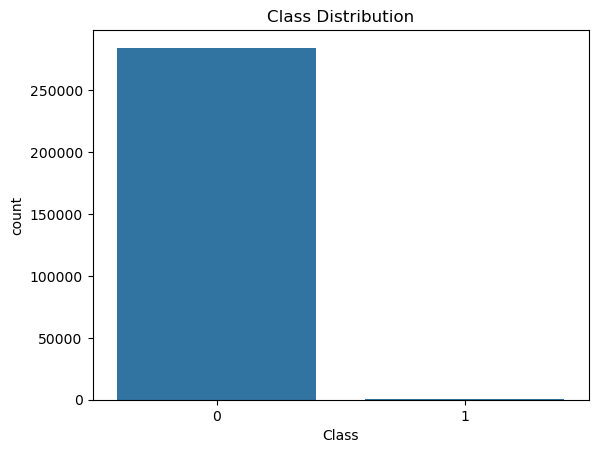

In [7]:
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')

In [8]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Correlation between features')

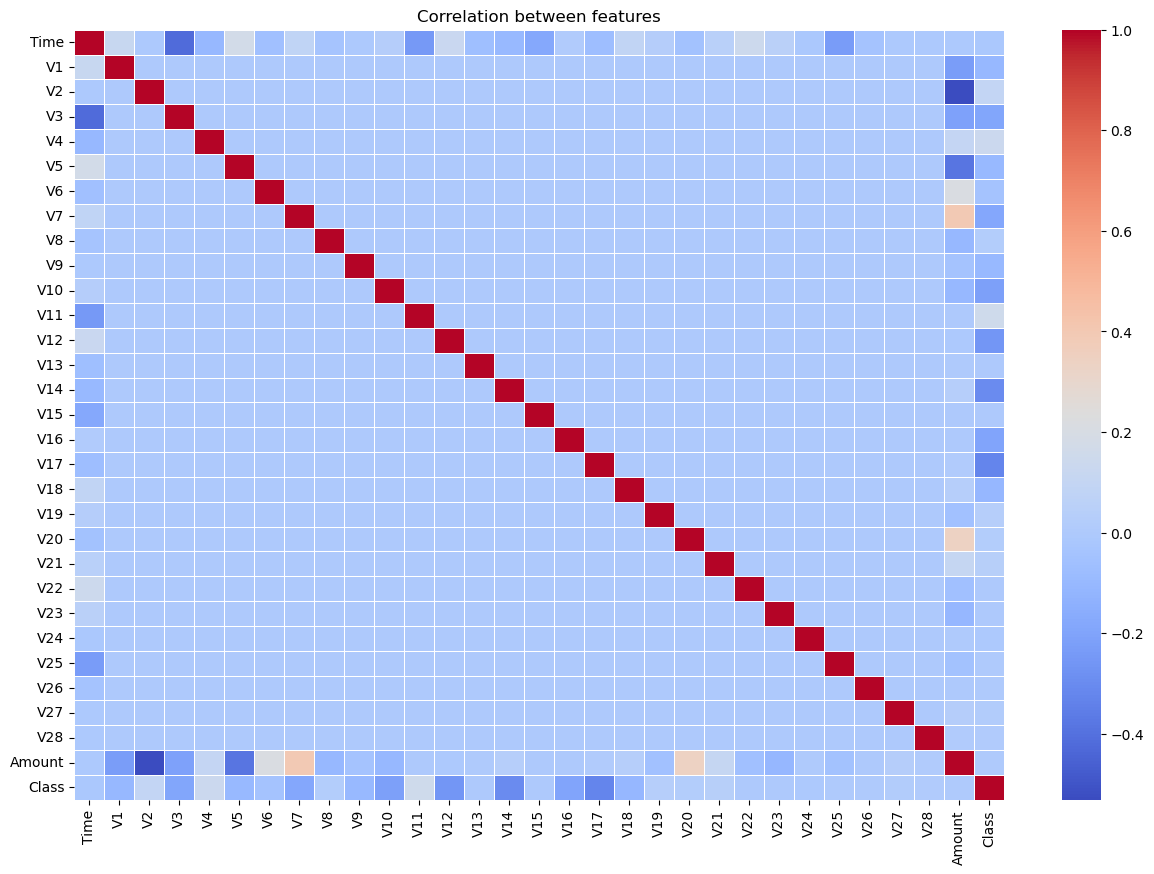

In [9]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation between features')

In [10]:
X = df.drop("Class",axis=1)

y_true = df["Class"] 

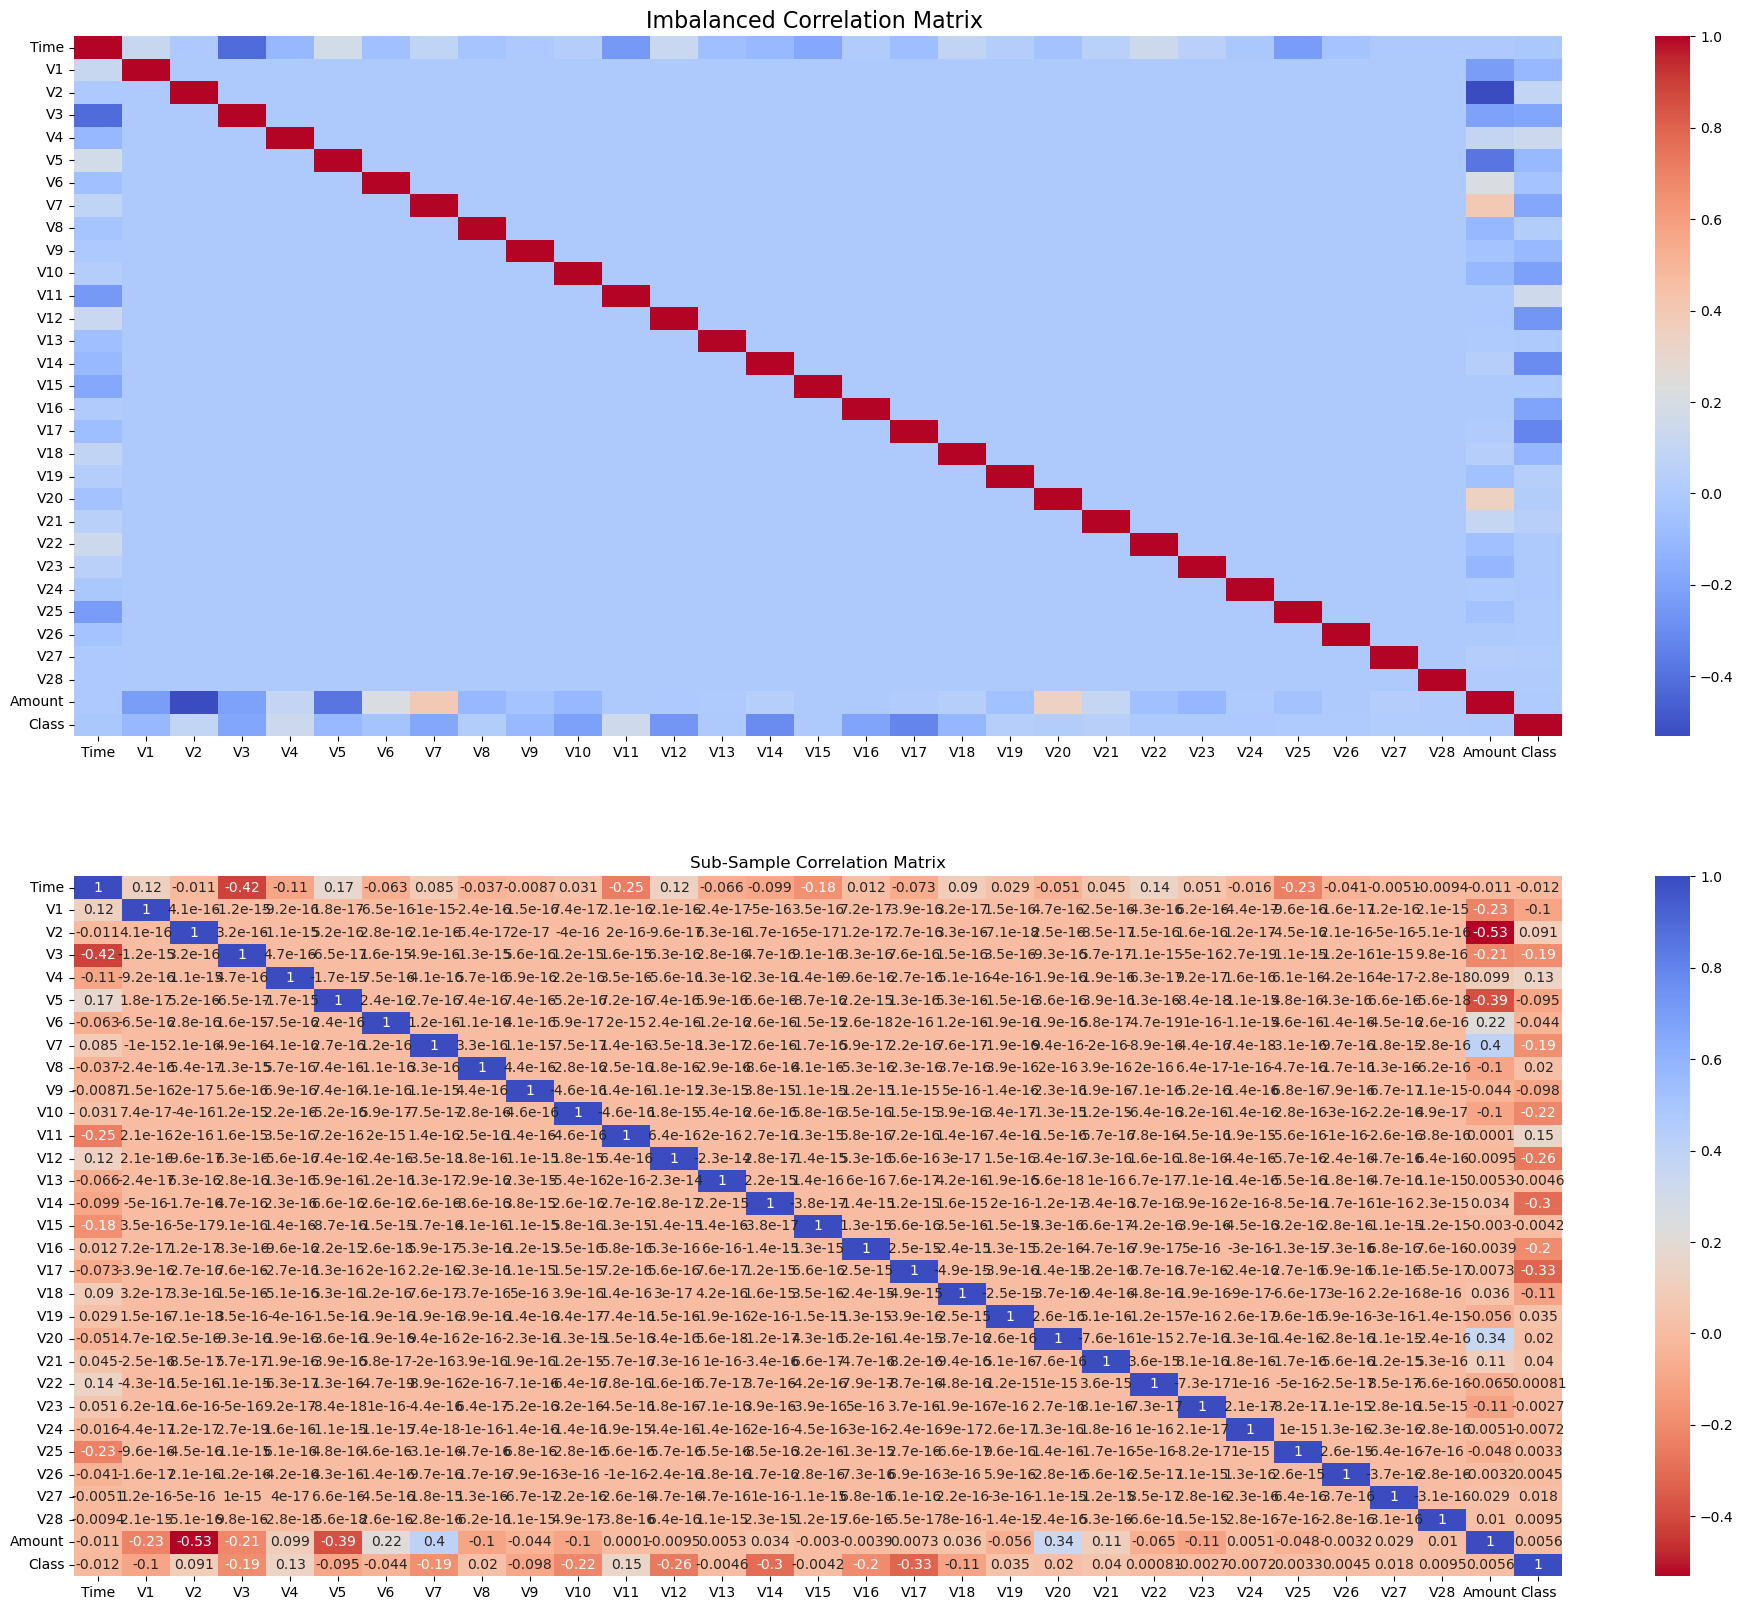

In [11]:
#  Correlation Heatmaps

# We compare the imbalanced vs balanced correlations to see the true relationships
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24,20))
#f contain the whole figure, ax1 and ax2 are the two subplots

# Imbalanced Correlation
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix ", fontsize=16)

# Balanced (Sub-sampled) Correlation
sns.heatmap(df.corr(), cmap='coolwarm_r', annot=True, ax=ax2)
ax2.set_title("Sub-Sample Correlation Matrix")
plt.show()

In [12]:
#sns.boxplot(X)
#plt.xticks(rotation=90)
#plt.title('Boxplot of features')

In [13]:
X["Amount"] = np.log1p(X["Amount"])

#sns.boxplot(X)
#plt.xticks(rotation=90)

In [14]:
# Check for Null Values
print(f"Missing values: {df.isnull().sum().max()}")

# Class Imbalance Check
fraud = round(df['Class'].value_counts()[1] / len(df) * 100, 2)
print(f'Frauds account for {fraud}% of the dataset')

Missing values: 0
Frauds account for 0.17% of the dataset


Text(0.5, 1.0, 'Correlation entre X et y')

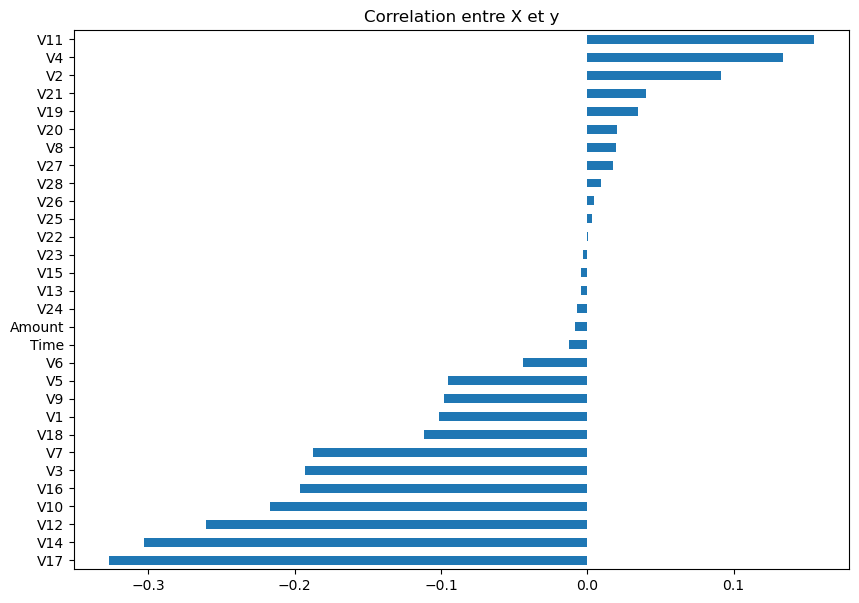

In [15]:
corre = X.join(y_true).corr()['Class'].drop("Class")

corr = corre.sort_values(key=abs,ascending=False)
corr.sort_values().plot(kind="barh",figsize=(10,7))

plt.title("Correlation entre X et y")

In [16]:
#Sélection des variables les plus corrélées avec la variable cible

corr = X.corrwith(y_true).abs().sort_values(ascending=False)

top20 = corr.head(20).index.tolist()

# Filtrer X
X_top20 = X[top20]

print(top20)

['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18', 'V1', 'V9', 'V5', 'V2', 'V6', 'V21', 'V19', 'V20', 'V8', 'V27']


In [17]:
X_top20.head()

,V17,V14,V12,V10,V16,V3,V7,V11,V4,V18,V1,V9,V5,V2,V6,V21,V19,V20,V8,V27
0,0.207971,-0.311169,-0.617801,0.090794,-0.470401,2.536347,0.239599,-0.551600,1.378155,0.025791,-1.359807,0.363787,-0.338321,-0.072781,0.462388,-0.018307,0.403993,0.251412,0.098698,0.133558
1,-0.114805,-0.143772,1.065235,-0.166974,0.463917,0.166480,-0.078803,1.612727,0.448154,-0.183361,1.191857,-0.255425,0.060018,0.266151,-0.082361,-0.225775,-0.145783,-0.069083,0.085102,-0.008983
2,1.109969,-0.165946,0.066084,0.207643,-2.890083,1.773209,0.791461,0.624501,0.379780,-0.121359,-1.358354,-1.514654,-0.503198,-1.340163,1.800499,0.247998,-2.261857,0.524980,0.247676,-0.055353
3,-0.684093,-0.287924,0.178228,-0.054952,-1.059647,1.792993,0.237609,-0.226487,-0.863291,1.965775,-0.966272,-1.387024,-0.010309,-0.185226,1.247203,-0.108300,-1.232622,-0.208038,0.377436,0.062723
4,-0.237033,-1.119670,0.538196,0.753074,-0.451449,1.548718,0.592941,-0.822843,0.403034,-0.038195,-1.158233,0.817739,-0.407193,0.877737,0.095921,-0.009431,0.803487,0.408542,-0.270533,0.219422


In [58]:
from sklearn.preprocessing import RobustScaler

In [59]:
normalizer = RobustScaler()
X_scaled = pd.DataFrame(normalizer.fit_transform(X_top20), columns=X_top20.columns)

In [60]:
X_scaled.head()

,V17,V14,V12,V10,V16,V3,V7,V11,V4,V18,V1,V9,V5,V2,V6,V21,V19,V20,V8,V27
0,0.309758,-0.393775,-0.740209,0.185689,-0.541507,1.228905,0.177406,-0.345414,0.878152,0.029437,-0.616237,0.334787,-0.217859,-0.098602,0.631245,0.026866,0.437322,0.910463,0.142432,0.816731
1,-0.055612,-0.211569,0.903686,-0.074854,0.400979,-0.006970,-0.105740,1.095465,0.293974,-0.179787,0.524929,-0.164482,0.087726,0.143100,0.164395,-0.473332,-0.163363,-0.019150,0.117064,-0.063781
2,1.330783,-0.235704,-0.072229,0.303796,-2.982344,0.830932,0.668164,0.437564,0.251024,-0.117763,-0.615587,-1.179796,-0.344345,-1.002407,1.778007,0.668917,-2.475385,1.703959,0.420388,-0.350218
3,-0.700023,-0.368473,0.037307,0.038374,-1.135905,0.841250,0.175637,-0.128974,-0.529808,1.970088,-0.440239,-1.076888,0.033775,-0.178789,1.303832,-0.190105,-1.350843,-0.422194,0.662489,0.379163
4,-0.193970,-1.273801,0.388903,0.855099,-0.522390,0.713861,0.491625,-0.525992,0.265632,-0.034570,-0.526089,0.700808,-0.270695,0.579239,0.317183,0.048266,0.873809,1.366227,-0.546463,1.347133


In [61]:
from sklearn.metrics import f1_score
from sklearn.ensemble import IsolationForest
# y: target (0 normal, 1 fraude)

contaminations = [0.0015,0.0017, 0.002, 0.003, 0.005, 0.007, 0.01, 0.02]
best = {"cont": None, "f1": -1}

for c in contaminations:
    clf = IsolationForest(
        n_estimators=100,
        contamination=c,
        random_state=42,
        n_jobs=1
    )
    clf.fit(X_scaled)
    y_pred = clf.predict(X_scaled)
    y_pred = np.where(y_pred == -1, 1, 0)

    f1 = f1_score(y_true, y_pred)
    print(f"contamination={c} -> F1={f1:.4f}")

    if f1 > best["f1"]:
        best["f1"] = f1
        best["cont"] = c

print("\nBest contamination:", best["cont"], "with F1:", best["f1"])


contamination=0.0015 -> F1=0.3326
contamination=0.0017 -> F1=0.3275
contamination=0.002 -> F1=0.3070
contamination=0.003 -> F1=0.2747
contamination=0.005 -> F1=0.2316
contamination=0.007 -> F1=0.2148
contamination=0.01 -> F1=0.1892
contamination=0.02 -> F1=0.1260

Best contamination: 0.0015 with F1: 0.33260869565217394


In [62]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=best["cont"], random_state=42)

model

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.0015
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [63]:
isolator = model.fit(X_scaled)

isolator

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.0015
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [64]:
y_pred = isolator.predict(X_scaled)

y_pred = np.where(y_pred == -1, 1, 0)

X_scaled

,V17,V14,V12,V10,V16,V3,V7,V11,V4,V18,V1,V9,V5,V2,V6,V21,V19,V20,V8,V27
0,0.309758,-0.393775,-0.740209,0.185689,-0.541507,1.228905,0.177406,-0.345414,0.878152,0.029437,-0.616237,0.334787,-0.217859,-0.098602,0.631245,0.026866,0.437322,0.910463,0.142432,0.816731
1,-0.055612,-0.211569,0.903686,-0.074854,0.400979,-0.006970,-0.105740,1.095465,0.293974,-0.179787,0.524929,-0.164482,0.087726,0.143100,0.164395,-0.473332,-0.163363,-0.019150,0.117064,-0.063781
2,1.330783,-0.235704,-0.072229,0.303796,-2.982344,0.830932,0.668164,0.437564,0.251024,-0.117763,-0.615587,-1.179796,-0.344345,-1.002407,1.778007,0.668917,-2.475385,1.703959,0.420388,-0.350218
3,-0.700023,-0.368473,0.037307,0.038374,-1.135905,0.841250,0.175637,-0.128974,-0.529808,1.970088,-0.440239,-1.076888,0.033775,-0.178789,1.303832,-0.190105,-1.350843,-0.422194,0.662489,0.379163
4,-0.193970,-1.273801,0.388903,0.855099,-0.522390,0.713861,0.491625,-0.525992,0.265632,-0.034570,-0.526089,0.700808,-0.270695,0.579239,0.317183,0.048266,0.873809,1.366227,-0.546463,1.347133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,2.328857,4.981193,2.512096,4.496984,1.050330,-5.222589,-4.409307,-1.038786,-1.285699,0.514445,-5.321622,1.585066,-4.073679,7.135767,-1.999082,0.585633,-0.750239,4.461946,13.588260,5.820867
284803,0.045259,-0.789948,0.757728,-0.892515,-0.784974,0.967471,-0.014027,-0.078179,-0.451476,-1.217961,-0.335820,0.512990,0.707747,-0.085979,1.142041,0.587444,-1.692755,0.354148,0.508439,0.414680
284804,0.429214,-0.610851,-0.075125,-0.396083,0.074952,-1.788463,-0.299623,0.295836,-0.337932,0.399426,0.850377,0.390154,2.059687,-0.261532,2.832770,0.630455,-0.634786,0.185279,1.280019,0.019227
284805,0.651561,0.434323,-1.077269,-0.309505,-0.680892,0.272567,-0.645865,-1.265633,0.445763,1.118001,-0.115629,0.357606,-0.248270,0.331602,0.769496,0.710499,3.162108,0.550857,1.225405,0.663921


In [65]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# X_scaled: tes variables déjà normalisées
# y: la colonne Class (0 normal, 1 fraude)

outlier_fraction = y_true.mean() 


print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))
print("F1:", f1_score(y_true, y_pred))


[[284040    275]
 [   339    153]]
              precision    recall  f1-score   support

           0     0.9988    0.9990    0.9989    284315
           1     0.3575    0.3110    0.3326       492

    accuracy                         0.9978    284807
   macro avg     0.6781    0.6550    0.6658    284807
weighted avg     0.9977    0.9978    0.9978    284807

F1: 0.33260869565217394


In [66]:

df_new = df.copy()
df_new["y_pred_isoforest"] = y_pred
df_new.head() 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,y_pred_isoforest
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0


In [67]:
df_new2 = X.copy()
df_new2["Class"] = y_true
df_new2["y_pred_iforest"] = y_pred

df_new2

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,y_pred_iforest
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,5.014760,0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,1.305626,0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,5.939276,0,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,4.824306,0,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,4.262539,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.570980,0,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,3.249987,0,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,4.232366,0,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,2.397895,0,0


In [68]:
X_s = X_scaled.copy()
y_s = y_true.copy()

In [69]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

In [70]:
#To manage imbalance data
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [71]:
from sklearn.tree import DecisionTreeClassifier

classeur = DecisionTreeClassifier()
classeur.fit(X_train_res, y_train_res)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [74]:
classeur.score(X_test, y_test)
#This score could make think that the model is in an overfitting, but when check its performance with
#other metrics, such as f1_score,classification_report,confusion_matrix we can see that the model
#it is not but it is just performing well. 

0.997471998876444

In [75]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix, f1_score

y_pred_rf = classeur.predict(X_test)

In [76]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("F1 Score:", f1_score(y_test, y_pred_rf))


MAE: 0.002528001123556055
RMSE: 0.05027923153306994
F1 Score: 0.5294117647058824


In [77]:
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.83      0.53        98

    accuracy                           1.00     56962
   macro avg       0.69      0.91      0.76     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56737   127]
 [   17    81]]


In [ ]:
import pandas as pd
import numpy as np

new_datasets = ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 
                    'V4', 'V18', 'V1', 'V9', 'V5', 'V2', 'V6', 'V21', 
                    'V19', 'V20', 'V8', 'V27']

# Creating 3 new virtual cases
new_transactions = pd.DataFrame([
    # Case 1: Standard Legitimate Transaction
    # Most V-features in the dataset are centered around 0 for normal cases
    [0.1, -0.2, 0.05, 0.1, -0.1, 0.3, 0.0, -0.2, 0.1, 0.05, 0.2, -0.1, 0.1, -0.05, 0.1, -0.01, 0.02, 0.01, -0.02, 0.01],
    
    # Case 2: Extreme Fraud (Strong negative signals in V17, V14, V12, V10)
    # These are usually the top "red flags" in the Credit Card dataset
    [-5.2, -7.1, -6.5, -4.8, -3.2, -2.5, -1.8, 4.2, 5.1, -2.1, -3.5, -2.0, -1.2, 2.5, -0.8, 0.7, 1.2, 0.5, 1.1, 0.3],
    
    # Case 3: Borderline/Subtle Fraud
    # Moderate negative values; testing if the model can catch a less obvious case
    [-1.5, -2.0, -1.8, -1.2, -1.0, -0.8, -0.5, 1.5, 1.2, -0.7, -1.0, -0.5, -0.3, 0.8, -0.2, 0.1, 0.3, 0.1, 0.2, 0.05]
], columns=new_datasets)

In [87]:
import pandas as pd

# 3 New profiles based on your raw data distribution
new_raw_data = pd.DataFrame([
    # Case A: Standard behavior (Values close to 0, similar to Row 1 & 3 of your sample)
    [0.15, -0.25, -0.40, 0.05, -0.30, 1.80, 0.15, -0.40, 1.10, 0.01, -1.10, 0.20, -0.20, -0.05, 0.35, -0.01, 0.30, 0.15, 0.05, 0.08],
    
    # Case B: Highly Suspicious (Strong negative shifts in V17, V14, V12 - the "Fraud Triad")
    [-4.50, -6.20, -5.80, -3.90, -2.80, -2.10, -1.50, 3.80, 4.50, -1.90, -3.20, -1.80, -1.00, 2.20, -0.70, 0.65, 1.10, 0.45, 1.00, 0.25],
    
    # Case C: Borderline/Noisy (Mixed signals, checking the model's sensitivity)
    [-0.80, 0.50, -1.20, -0.50, 1.10, 0.90, -0.40, 1.20, -0.50, 0.80, 0.30, 0.60, -0.40, 0.40, -0.10, 0.05, -0.20, -0.05, 0.15, -0.02]
], columns=['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18', 'V1', 'V9', 'V5', 'V2', 'V6', 'V21', 'V19', 'V20', 'V8', 'V27'])

In [88]:
X_test.columns

Index(['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18', 'V1',
       'V9', 'V5', 'V2', 'V6', 'V21', 'V19', 'V20', 'V8', 'V27'],
      dtype='object')

In [89]:
new_transactions.columns

Index(['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18', 'V1',
       'V9', 'V5', 'V2', 'V6', 'V21', 'V19', 'V20', 'V8', 'V27'],
      dtype='object')

In [90]:
X_top20[0:4]

,V17,V14,V12,V10,V16,V3,V7,V11,V4,V18,V1,V9,V5,V2,V6,V21,V19,V20,V8,V27
0,0.207971,-0.311169,-0.617801,0.090794,-0.470401,2.536347,0.239599,-0.551600,1.378155,0.025791,-1.359807,0.363787,-0.338321,-0.072781,0.462388,-0.018307,0.403993,0.251412,0.098698,0.133558
1,-0.114805,-0.143772,1.065235,-0.166974,0.463917,0.166480,-0.078803,1.612727,0.448154,-0.183361,1.191857,-0.255425,0.060018,0.266151,-0.082361,-0.225775,-0.145783,-0.069083,0.085102,-0.008983
2,1.109969,-0.165946,0.066084,0.207643,-2.890083,1.773209,0.791461,0.624501,0.379780,-0.121359,-1.358354,-1.514654,-0.503198,-1.340163,1.800499,0.247998,-2.261857,0.524980,0.247676,-0.055353
3,-0.684093,-0.287924,0.178228,-0.054952,-1.059647,1.792993,0.237609,-0.226487,-0.863291,1.965775,-0.966272,-1.387024,-0.010309,-0.185226,1.247203,-0.108300,-1.232622,-0.208038,0.377436,0.062723


In [91]:
new_transactions

,V17,V14,V12,V10,V16,V3,V7,V11,V4,V18,V1,V9,V5,V2,V6,V21,V19,V20,V8,V27
0,0.1,-0.2,0.05,0.1,-0.1,0.3,0.0,-0.2,0.1,0.05,0.2,-0.1,0.1,-0.05,0.1,-0.01,0.02,0.01,-0.02,0.01
1,-5.2,-7.1,-6.50,-4.8,-3.2,-2.5,-1.8,4.2,5.1,-2.10,-3.5,-2.0,-1.2,2.50,-0.8,0.70,1.20,0.50,1.10,0.30
2,-1.5,-2.0,-1.80,-1.2,-1.0,-0.8,-0.5,1.5,1.2,-0.70,-1.0,-0.5,-0.3,0.80,-0.2,0.10,0.30,0.10,0.20,0.05


In [92]:
new_transactions.shape

(3, 20)

In [93]:
new_raw_data

,V17,V14,V12,V10,V16,V3,V7,V11,V4,V18,V1,V9,V5,V2,V6,V21,V19,V20,V8,V27
0,0.15,-0.25,-0.4,0.05,-0.3,1.8,0.15,-0.4,1.1,0.01,-1.1,0.2,-0.2,-0.05,0.35,-0.01,0.3,0.15,0.05,0.08
1,-4.50,-6.20,-5.8,-3.90,-2.8,-2.1,-1.50,3.8,4.5,-1.90,-3.2,-1.8,-1.0,2.20,-0.70,0.65,1.1,0.45,1.00,0.25
2,-0.80,0.50,-1.2,-0.50,1.1,0.9,-0.40,1.2,-0.5,0.80,0.3,0.6,-0.4,0.40,-0.10,0.05,-0.2,-0.05,0.15,-0.02


In [94]:
new_raw_data.shape

(3, 20)

In [96]:
from sklearn.preprocessing import RobustScaler

normalizer = RobustScaler()
new_transactions_scaled = pd.DataFrame(normalizer.fit_transform(new_transactions), columns=new_transactions.columns)

new_transactions_scaled

,V17,V14,V12,V10,V16,V3,V7,V11,V4,V18,V1,V9,V5,V2,V6,V21,V19,V20,V8,V27
0,0.603774,0.521739,0.564885,0.530612,0.580645,0.785714,0.555556,-0.772727,-0.44,0.697674,0.648649,0.421053,0.615385,-0.666667,0.666667,-0.309859,-0.474576,-0.367347,-0.392857,-0.275862
1,-1.396226,-1.478261,-1.435115,-1.469388,-1.419355,-1.214286,-1.444444,1.227273,1.56,-1.302326,-1.351351,-1.578947,-1.384615,1.333333,-1.333333,1.690141,1.525424,1.632653,1.607143,1.724138
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [97]:
new_raw_data_scaled = pd.DataFrame(normalizer.fit_transform(new_raw_data), columns=new_raw_data.columns)

new_raw_data_scaled

,V17,V14,V12,V10,V16,V3,V7,V11,V4,V18,V1,V9,V5,V2,V6,V21,V19,V20,V8,V27
0,0.408602,0.000000,0.296296,0.278481,0.000000,0.461538,0.666667,-0.761905,0.00,0.000000,0.0,0.000000,0.5,-0.4,0.857143,-0.181818,0.000000,0.0,-0.210526,0.000000
1,-1.591398,-1.776119,-1.703704,-1.721519,-1.282051,-1.538462,-1.333333,1.238095,1.36,-1.414815,-1.2,-1.666667,-1.5,1.6,-1.142857,1.818182,1.230769,1.2,1.789474,1.259259
2,0.000000,0.223881,0.000000,0.000000,0.717949,0.000000,0.000000,0.000000,-0.64,0.585185,0.8,0.333333,0.0,0.0,0.000000,0.000000,-0.769231,-0.8,0.000000,-0.740741


In [109]:
new_transactions_predictions = model.predict(new_transactions_scaled)
print("Predicted classes for new transactions data")
new_transactions_predictions

Predicted classes for new transactions data


array([1, 1, 1])

In [108]:
new_raw_data_scaled_predictions = model.predict(new_raw_data_scaled)

print("Predicted classes for new raw data:")
new_raw_data_scaled_predictions

Predicted classes for new raw data:


array([1, 1, 1])